In [1]:
# initial submission score 0.56376 - lightGBM

### **Grupo Bimbo Kaggle**

Notebook para la competición. Atención necesita mucha memoria (unos 64GB de RAM)

#### Feature Engineering Summary

#### 1. Drop leaky / unavailable columns

Columns present in train but not in test are dropped immediately:

- `Venta_uni_hoy`, `Venta_hoy`, `Dev_uni_proxima`, `Dev_proxima` — sales/returns figures
- `Semana` — week number (would cause temporal leakage)

#### 2. Product enrichment (`producto_tabla`)

Regex parsing of the product name string produces:

| Field | Description |
|---|---|
| `popular_name` | Base product name (e.g. `"Bimbollos"`) |
| `property` | Brand/line tag (e.g. `"Prom BIM"`) |
| `pieces` | Unit count |
| `unit` → `weight` | Package weight in grams |
| `price` | Median sale price per product |

Missing prices and weights are imputed via a `LinearRegression` fit on the `weight ↔ price` relationship.

#### 3. Geographic feature (`town_state`)

- `Agencia_ID` is replaced by `Town_ID` — coarser geography, lower cardinality
- `Agencia_ID` is then dropped

#### 4. Demand aggregation features (4 levels)

These are the most predictive features. Median `Demanda_uni_equil` is computed on the full training set and merged in as a lookup:

| Feature | Grouping key | Purpose |
|---|---|---|
| `client_med` | `Cliente_ID` | Historical demand per client |
| `popular_name_med` | product name | Demand by product family |
| `town_id_med` | `Town_ID` | Demand by geography |
| `ruta_id_med` | `Ruta_SAK` | Demand by delivery route |

After merging, the original ID columns (`Cliente_ID`, `Producto_ID`, `Ruta_SAK`, `Town_ID`, `popular_name`, `property`, `pieces`) are all dropped — the model only sees the aggregated statistics, not the raw IDs.

`NaN` values (cold-start rows with no history) are filled with the training-set column mean.

#### 5. BoxCox transform on skewed features

Any numerical column with `|skew| ≥ 0.75` gets `boxcox1p(x, λ=0.01)`, applied identically to both train and test.

#### 6. Categorical encoding

- `Canal_ID` and `State` are cast to `category`
- Final step: `pd.get_dummies()` one-hot-encodes all categoricals for the model

#### 7. Target transform (inside `MyEstimator`)

- **Training:** `log1p(y)` applied internally so RMSE on log scale = RMSLE
- **Prediction:** `expm1()` applied internally to return raw demand units

#### Summary

The notebook replaces raw IDs with median-demand statistics at **4 hierarchical levels** (client, product family, town, route), enriches products with physical attributes (weight, price), and normalises skewed features with BoxCox — all before one-hot encoding and tree-based modeling.



In [2]:
import re
import numpy as np
import pandas as pd
from pandas.core.dtypes.dtypes import CategoricalDtype
from scipy.stats import norm, skew
from scipy.special import boxcox1p
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))
pd.set_option("display.max_columns", 81)
pd.set_option("display.max_rows", 101)
pd.set_option("display.max_colwidth", 100)

'''Seaborn and Matplotlib Visualization'''
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('bmh')                    
sns.set_style({'axes.grid':False}) 
sns.set_style('whitegrid')
%matplotlib inline

'''Importing Modeling Interested Modules'''
from sklearn.base import BaseEstimator
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from lightgbm import LGBMRegressor
import lightgbm as lgb
import xgboost as xgb

'''Validation'''
from sklearn.model_selection import KFold, cross_val_score

'''Ignore deprecation and future, and user warnings.'''
import warnings as wrn
wrn.filterwarnings('ignore', category = DeprecationWarning) 
wrn.filterwarnings('ignore', category = FutureWarning) 
wrn.filterwarnings('ignore', category = UserWarning) 
import gc


In [3]:
path = './data/'
from subprocess import check_output
print(check_output(["ls", path]).decode("utf8"))

cliente_tabla.csv
cliente_tabla.csv.zip
Client_Table_Filtered.csv
producto_tabla.csv
producto_tabla.csv.zip
SampleBimbo.csv
sample_submission.csv
sample_submission.csv.zip
test.csv
test.csv.zip
town_state.csv
town_state.csv.zip
train.csv
train.csv.zip
trainsample.csv
Untitled.ipynb



#### **town_state**
Creation of new column with State by splitting the original Agencia_ID 

In [4]:
dtype = {'Agencia_ID': 'int16'}
town_state_df = pd.read_csv(path + "town_state.csv.zip", dtype=dtype)
town_state_df.head()

,Agencia_ID,Town,State
0,1110,2008 AG. LAGO FILT,"MÉXICO, D.F."
1,1111,2002 AG. AZCAPOTZALCO,"MÉXICO, D.F."
2,1112,2004 AG. CUAUTITLAN,ESTADO DE MÉXICO
3,1113,2008 AG. LAGO FILT,"MÉXICO, D.F."
4,1114,2029 AG.IZTAPALAPA 2,"MÉXICO, D.F."


In [5]:
town_state_df['Town_ID'] = town_state_df.Town.apply(lambda x: x.split(' ')[0]).astype('int16')
town_state_df['Town_name'] = town_state_df.Town.apply(lambda x: ' '.join(x.split(' ')[1:]))

print(f'town_state\'s shape: {town_state_df.shape}')
town_state_df.head(5)

town_state's shape: (790, 5)


,Agencia_ID,Town,State,Town_ID,Town_name
0,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",2008,AG. LAGO FILT
1,1111,2002 AG. AZCAPOTZALCO,"MÉXICO, D.F.",2002,AG. AZCAPOTZALCO
2,1112,2004 AG. CUAUTITLAN,ESTADO DE MÉXICO,2004,AG. CUAUTITLAN
3,1113,2008 AG. LAGO FILT,"MÉXICO, D.F.",2008,AG. LAGO FILT
4,1114,2029 AG.IZTAPALAPA 2,"MÉXICO, D.F.",2029,AG.IZTAPALAPA 2


In [6]:
town_state_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 790 entries, 0 to 789
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Agencia_ID  790 non-null    int16
 1   Town        790 non-null    str  
 2   State       790 non-null    str  
 3   Town_ID     790 non-null    int16
 4   Town_name   790 non-null    str  
dtypes: int16(2), str(3)
memory usage: 21.7 KB


#### **product**

In [7]:
dtype = {'Producto_ID': 'int32'}
product_df = pd.read_csv(path+"producto_tabla.csv.zip", dtype=dtype)
product_df.head()

,Producto_ID,NombreProducto
0,0,NO IDENTIFICADO 0
1,9,Capuccino Moka 750g NES 9
2,41,Bimbollos Ext sAjonjoli 6p 480g BIM 41
3,53,Burritos Sincro 170g CU LON 53
4,72,Div Tira Mini Doradita 4p 45g TR 72


In [8]:
product_df['popular_name'] = product_df.NombreProducto.str.extract(r'^(.*?)(\d*\s\d+(kg|Kg|g|G|ml| ml|p|Reb)\s)', expand=False)[0]
product_df['property'] = product_df.NombreProducto.str.extract(r'^.*\d+(kg|Kg|g|G|ml| ml|p|Reb)\s(.*?)\s\d+$', expand=False)[1]
product_df['unit'] = product_df.NombreProducto.str.extract(r'(\d*\s\d+(kg|Kg|g|G|ml| ml))', expand=False)[0]
product_df['pieces'] =  product_df.NombreProducto.str.extract('(\d+(p|Reb)) ', expand=False)[0]

print(f'product\'s shape: {product_df.shape}')
product_df.head(5)

product's shape: (2592, 6)


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_29247/201434978.py:4: SyntaxWarning: invalid escape sequence '\d'
  product_df['pieces'] =  product_df.NombreProducto.str.extract('(\d+(p|Reb)) ', expand=False)[0]


,Producto_ID,NombreProducto,popular_name,property,unit,pieces
0,0,NO IDENTIFICADO 0,NaN,NaN,NaN,NaN
1,9,Capuccino Moka 750g NES 9,Capuccino Moka,NES,750g,NaN
2,41,Bimbollos Ext sAjonjoli 6p 480g BIM 41,Bimbollos Ext sAjonjoli,BIM,480g,6p
3,53,Burritos Sincro 170g CU LON 53,Burritos Sincro,CU LON,170g,NaN
4,72,Div Tira Mini Doradita 4p 45g TR 72,Div Tira Mini Doradita,TR,45g,4p


In [9]:
product_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2592 entries, 0 to 2591
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Producto_ID     2592 non-null   int32
 1   NombreProducto  2592 non-null   str  
 2   popular_name    2565 non-null   str  
 3   property        2571 non-null   str  
 4   unit            2532 non-null   str  
 5   pieces          1132 non-null   str  
dtypes: int32(1), str(5)
memory usage: 111.5 KB


#### **client**

In [10]:
dtype = {'Cliente_ID': 'int32'}
client_df = pd.read_csv(path+"cliente_tabla.csv.zip", dtype=dtype)

dup_sr = client_df.groupby('Cliente_ID')['Cliente_ID'].count().astype('int8')
dup_sr.name = 'dup_num'
client_df = pd.merge(client_df, pd.DataFrame(dup_sr).reset_index())
del dup_sr

print(f'client\'s shape: {client_df.shape}')
client_df.head(5)

client's shape: (935362, 3)


,Cliente_ID,NombreCliente,dup_num
0,0,SIN NOMBRE,1
1,1,OXXO XINANTECATL,1
2,2,SIN NOMBRE,1
3,3,EL MORENO,1
4,4,SDN SER DE ALIM CUERPO SA CIA DE INT,2


In [11]:
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 935362 entries, 0 to 935361
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Cliente_ID     935362 non-null  int32
 1   NombreCliente  935362 non-null  str  
 2   dup_num        935362 non-null  int8 
dtypes: int32(1), int8(1), str(1)
memory usage: 11.6 MB


#### structure test file
test file will be used for the final submission

In [12]:
dtype = {
    'id': 'int32',
    'Semana': 'int8',
    'Agencia_ID': 'int16',
    'Canal_ID': 'int8',
    'Ruta_SAK': 'int16',
    'Cliente_ID': 'int32',
    'Producto_ID': 'int32',
}
test_df = pd.read_csv(path+"test.csv.zip", dtype=dtype)

print(f'test\'s shape: {test_df.shape}')
test_df.head()

test's shape: (6999251, 7)


,id,Semana,Agencia_ID,Canal_ID,Ruta_SAK,Cliente_ID,Producto_ID
0,0,11,4037,1,2209,4639078,35305
1,1,11,2237,1,1226,4705135,1238
2,2,10,2045,1,2831,4549769,32940
3,3,11,1227,1,4448,4717855,43066
4,4,11,1219,1,1130,966351,1277


In [13]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6999251 entries, 0 to 6999250
Data columns (total 7 columns):
 #   Column       Dtype
---  ------       -----
 0   id           int32
 1   Semana       int8 
 2   Agencia_ID   int16
 3   Canal_ID     int8 
 4   Ruta_SAK     int16
 5   Cliente_ID   int32
 6   Producto_ID  int32
dtypes: int16(2), int32(3), int8(2)
memory usage: 120.2 MB


#### **training file**
Train file to develop model

In [14]:
dtype = {
    'Semana': 'int8',
    'Agencia_ID': 'int16',
    'Canal_ID': 'int8',
    'Ruta_SAK': 'int16',
    'Cliente_ID': 'int32',
    'Producto_ID': 'int32',
    'Venta_uni_hoy': 'int16',
    'Venta_hoy': 'float32',
    'Dev_uni_proxima': 'int32',
    'Dev_proxima': 'float32',
    'Demanda_uni_equil': 'int16',
}
train_df = pd.read_csv(path+"train.csv.zip", dtype=dtype)

print(f'train\'s shape: {train_df.shape}')
train_df.head()

train's shape: (74180464, 11)


,Semana,Agencia_ID,Canal_ID,Ruta_SAK,Cliente_ID,Producto_ID,Venta_uni_hoy,Venta_hoy,Dev_uni_proxima,Dev_proxima,Demanda_uni_equil
0,3,1110,7,3301,15766,1212,3,25.140,0,0.000,3
1,3,1110,7,3301,15766,1216,4,33.520,0,0.000,4
2,3,1110,7,3301,15766,1238,4,39.320,0,0.000,4
3,3,1110,7,3301,15766,1240,4,33.520,0,0.000,4
4,3,1110,7,3301,15766,1242,3,22.920,0,0.000,3


In [15]:
print('max: %s' % train_df['Demanda_uni_equil'].max())
print('min: %s' % train_df['Demanda_uni_equil'].min())
print('avg: %s' % train_df['Demanda_uni_equil'].mean())

max: 5000
min: 0
avg: 7.2245640038056385


In [16]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74180464 entries, 0 to 74180463
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Semana             int8   
 1   Agencia_ID         int16  
 2   Canal_ID           int8   
 3   Ruta_SAK           int16  
 4   Cliente_ID         int32  
 5   Producto_ID        int32  
 6   Venta_uni_hoy      int16  
 7   Venta_hoy          float32
 8   Dev_uni_proxima    int32  
 9   Dev_proxima        float32
 10  Demanda_uni_equil  int16  
dtypes: float32(2), int16(4), int32(3), int8(2)
memory usage: 2.1 GB


### product_price

In [17]:
sale_price_sr = (train_df.Venta_hoy / train_df.Venta_uni_hoy)
return_price_sr = (train_df.Dev_proxima / train_df.Dev_uni_proxima)
product_price_df = pd.DataFrame({'Producto_ID': train_df.Producto_ID, 'sale_price': sale_price_sr, 'return_price': return_price_sr})

del sale_price_sr
del return_price_sr

print(f'product price\'s shape: {product_price_df.shape}')
product_price_df.head(5)

product price's shape: (74180464, 3)


,Producto_ID,sale_price,return_price
0,1212,8.380,NaN
1,1216,8.380,NaN
2,1238,9.830,NaN
3,1240,8.380,NaN
4,1242,7.640,NaN


In [18]:
product_price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74180464 entries, 0 to 74180463
Data columns (total 3 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Producto_ID   int32  
 1   sale_price    float32
 2   return_price  float64
dtypes: float32(1), float64(1), int32(1)
memory usage: 1.1 GB


#### **Defining Evaluation**

In [19]:
'''KFold for cross validation'''
kf = KFold(n_splits=3, shuffle=True, random_state=2)

'''Define the validation function'''
def rmsle_cv(model, X, y, cv=kf):
    rmsle = np.sqrt(
        -cross_val_score(
            model,
            X, y,
            scoring="neg_mean_squared_log_error",
            cv=cv,
        )
    )
    return(rmsle)

##### **Data Cleaning**

#### town_state

In [20]:
town_state_df['Town'] = town_state_df['Town'].str.upper()
town_state_df['Town_name'] = town_state_df['Town_name'].str.upper()
town_state_df['State'] = town_state_df['State'].str.upper()

In [21]:
town_state_df.groupby(['Town_name'])['Town_ID'].nunique().sort_values(ascending=False)[:6]

Town_name
PINOTEPA       2
LOS MOCHIS     2
ACAPONETA      1
NOGALES_BW     1
NORTE          1
NUEVO IDEAL    1
Name: Town_ID, dtype: int64

In [22]:
town_state_df[(town_state_df['Town_name'].isin(['LOS MOCHIS', 
                                                'PINOTEPA']))].sort_values(by='Town_name')

,Agencia_ID,Town,State,Town_ID,Town_name
211,1544,2561 LOS MOCHIS,SINALOA,2561,LOS MOCHIS
227,1564,2561 LOS MOCHIS,SINALOA,2561,LOS MOCHIS
248,1598,2561 LOS MOCHIS,SINALOA,2561,LOS MOCHIS
498,2655,2655 LOS MOCHIS,SINALOA,2655,LOS MOCHIS
774,25619,2561 LOS MOCHIS,SINALOA,2561,LOS MOCHIS
372,2023,2169 PINOTEPA,OAXACA,2169,PINOTEPA
387,2055,2055 PINOTEPA,PUEBLA,2055,PINOTEPA
599,21699,2169 PINOTEPA,OAXACA,2169,PINOTEPA


In [23]:
town_state_df.loc[498, 'Town_ID'] = 2561

In [24]:
town_state_df.head(5)

,Agencia_ID,Town,State,Town_ID,Town_name
0,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",2008,AG. LAGO FILT
1,1111,2002 AG. AZCAPOTZALCO,"MÉXICO, D.F.",2002,AG. AZCAPOTZALCO
2,1112,2004 AG. CUAUTITLAN,ESTADO DE MÉXICO,2004,AG. CUAUTITLAN
3,1113,2008 AG. LAGO FILT,"MÉXICO, D.F.",2008,AG. LAGO FILT
4,1114,2029 AG.IZTAPALAPA 2,"MÉXICO, D.F.",2029,AG.IZTAPALAPA 2


In [25]:
town_state_df.groupby('Town_ID')['Town'].nunique().sort_values(ascending=False)

Town_ID
2169    2
2152    2
2561    2
2001    1
2391    1
       ..
2257    1
2258    1
2259    1
2260    1
3216    1
Name: Town, Length: 256, dtype: int64

In [26]:
town_state_df[town_state_df.Town_ID.isin([2561, 2169, 2152])].sort_values(by='Town_ID')

,Agencia_ID,Town,State,Town_ID,Town_name
199,1524,2152 CRUCE DE ANDEN NOROESTE,BAJA CALIFORNIA NORTE,2152,CRUCE DE ANDEN NOROESTE
371,2022,2152 ALTAMIRANO_BM,GUERRERO,2152,ALTAMIRANO_BM
583,21529,2152 ALTAMIRANO_BM,GUERRERO,2152,ALTAMIRANO_BM
311,1694,2169 CRUCE DE ANDÉN SURESTE,PUEBLA,2169,CRUCE DE ANDÉN SURESTE
372,2023,2169 PINOTEPA,OAXACA,2169,PINOTEPA
599,21699,2169 PINOTEPA,OAXACA,2169,PINOTEPA
211,1544,2561 LOS MOCHIS,SINALOA,2561,LOS MOCHIS
227,1564,2561 LOS MOCHIS,SINALOA,2561,LOS MOCHIS
248,1598,2561 LOS MOCHIS,SINALOA,2561,LOS MOCHIS
498,2655,2655 LOS MOCHIS,SINALOA,2561,LOS MOCHIS


In [27]:
town_state_df['Town_ID'].max()

np.int16(3216)

In [28]:
town_state_df.loc[199, 'Town_ID'] = 3217
town_state_df.loc[311, 'Town_ID'] = 3218

In [29]:
town_state_df['Town_ID'].nunique()

258

#### product_price

In [30]:
sale_prices_df = product_price_df.drop('return_price', axis=1).dropna().rename(columns={'sale_price': 'price'})
return_prices_df = product_price_df.drop('sale_price', axis=1).dropna().rename(columns={'return_price': 'price'})
prices_df = pd.concat([sale_prices_df, return_prices_df])
prices_df = prices_df.groupby('Producto_ID')['price'].median().reset_index()
del product_price_df, sale_prices_df, return_prices_df  # no longer needed
gc.collect()
prices_df.head(5)


,Producto_ID,price
0,41,18.130
1,53,14.300
2,72,3.700
3,73,21.320
4,100,21.580


In [31]:
prices_df.shape

(1799, 2)

#### product

In [32]:
product_df['in_train'] = 0
product_df['in_test'] = 0
product_df.loc[product_df['Producto_ID'].isin(test_df['Producto_ID'].unique()), 'in_test'] = 1
product_df.loc[product_df['Producto_ID'].isin(train_df['Producto_ID'].unique()), 'in_train'] = 1
product_df = product_df[(product_df['in_test'] == 1) | (product_df['in_train'] == 1)]

In [33]:
product_df[product_df['property'].isnull()]

,Producto_ID,NombreProducto,popular_name,property,unit,pieces,in_train,in_test
117,1289,Donas 6P Prom BIM 1289,NaN,NaN,NaN,NaN,1,0
190,3509,Paletina para Cafe NES 3509,NaN,NaN,NaN,NaN,1,0
381,30099,Camioncitos Bimbo BIM 30099,NaN,NaN,NaN,NaN,1,1
1152,34646,Burrito Vaporero FrijolChorizo90gCU LON 34646,NaN,NaN,NaN,NaN,1,1
1677,36659,Tarima Twin Pack Thins Multig CU ORO 36659,NaN,NaN,NaN,NaN,1,1
1888,37569,Deliciosas Chochochispas 204gPromMTA LAR 37569,NaN,NaN,204g,NaN,1,1
1889,37570,Deliciosas Chochochispas 204gProm LAR 37570,NaN,NaN,204g,NaN,1,1
2449,48033,Galleta Granel Classics Chocolate GBI 48033,NaN,NaN,NaN,NaN,1,1


In [34]:
product_df.loc[117, 'popular_name'] = 'Donas'
product_df.loc[117, 'property'] = 'Prom BIM'
product_df.loc[117, 'unit'] = None
product_df.loc[117, 'pieces'] = '6p'

product_df.loc[190, 'popular_name'] = 'Paletina para Cafe'
product_df.loc[190, 'property'] = 'NES'
product_df.loc[190, 'unit'] = None
product_df.loc[190, 'pieces'] = None

product_df.loc[381, 'popular_name'] = 'Camioncitos Bimbo'
product_df.loc[381, 'property'] = 'BIM'
product_df.loc[381, 'unit'] = None
product_df.loc[381, 'pieces'] = None

product_df.loc[1152, 'popular_name'] = 'Burrito Vaporero FrijolChorizo'
product_df.loc[1152, 'property'] = 'CU LON'
product_df.loc[1152, 'unit'] = '90g'
product_df.loc[1152, 'pieces'] = None

product_df.loc[1677, 'popular_name'] = 'Tarima Twin Pack Thins Multig'
product_df.loc[1677, 'property'] = 'CU ORO'
product_df.loc[1677, 'unit'] = None
product_df.loc[1677, 'pieces'] = None

product_df.loc[1888, 'popular_name'] = 'Deliciosas Chochochispas'
product_df.loc[1888, 'property'] = 'Prom MTA LAR'
product_df.loc[1888, 'unit'] = '204g'
product_df.loc[1888, 'pieces'] = None

product_df.loc[1889, 'popular_name'] = 'Deliciosas Chochochispas'
product_df.loc[1889, 'property'] = 'Prom LAR'
product_df.loc[1889, 'unit'] = '204g'
product_df.loc[1889, 'pieces'] = None

product_df.loc[2449, 'popular_name'] = 'Galleta Granel Classics Chocolate'
product_df.loc[2449, 'property'] = 'GBI'
product_df.loc[2449, 'unit'] = None
product_df.loc[2449, 'pieces'] = None

In [35]:
product_df[product_df['popular_name'].isnull()]

,Producto_ID,NombreProducto,popular_name,property,unit,pieces,in_train,in_test
877,32841,Tortilla Hna Chihuahua 10p535g SP MTA DH 32841,NaN,SP MTA DH,NaN,NaN,1,1
1585,36323,Principe Cho Bco MG 10p110g Prom CR1 MLA 36323,NaN,Prom CR1 MLA,NaN,NaN,1,1
1748,36927,Combo Salma mas Levite1360g Prom CUB SAN 36927,NaN,Prom CUB SAN,NaN,NaN,1,0


In [36]:
product_df.loc[877, 'popular_name'] = 'Tortilla Hna Chihuahua'
product_df.loc[877, 'unit'] = '535g'
product_df.loc[877, 'pieces'] = '10p'

product_df.loc[1585, 'popular_name'] = 'Principe Cho Bco MG'
product_df.loc[1585, 'unit'] = '110g'
product_df.loc[1585, 'pieces'] = '10p'

product_df.loc[1748, 'popular_name'] = 'Combo Salma mas Levite'
product_df.loc[1748, 'unit'] = '1360g'
product_df.loc[1748, 'pieces'] = None

In [37]:
product_df['pieces'] = product_df['pieces'].str.extract(r'(\d+)(p|Reb)')[0]

In [38]:
product_df['weight'] = product_df['unit'].str.strip()
product_df['weight'] = product_df['weight'].str.replace(' ', '.')
product_df['weight'] = product_df['weight'].str.upper()
w = product_df['weight'].str.extract('(.+?)(KG|G|ML)', expand=True)
product_df['weight'] = w[0].astype('float') * w[1].map({'KG':1000, 'G':1, 'ML':1})

In [39]:
product_df = pd.merge(product_df, prices_df, how='left')

#### **Imputing Missing Data**

#### product

In [40]:
product_df['pieces'] = product_df['pieces'].fillna(1)

In [41]:
product_df[product_df['weight'].isnull()]['price'].max()

np.float64(311.0)

In [42]:
product_df[product_df['price'].isnull()]['weight'].max()

np.float64(1880.0)

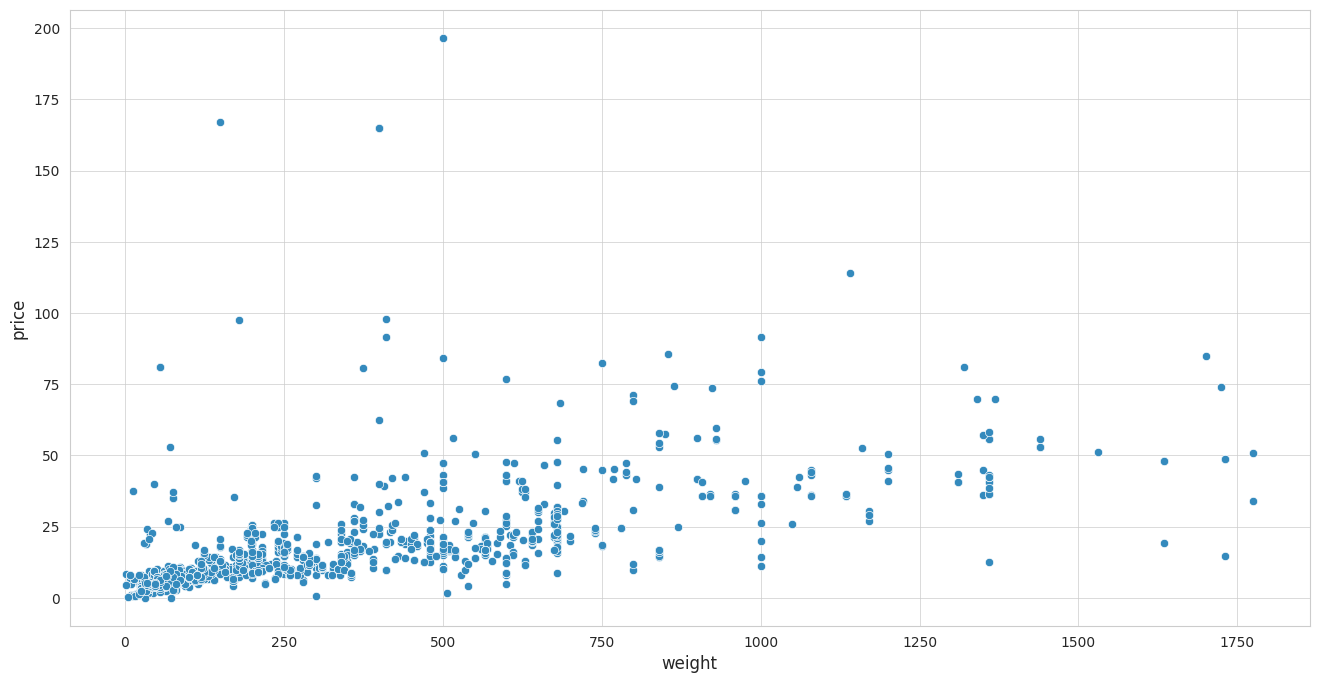

In [43]:
df = product_df.dropna()
df = df[(df['price'] <= 311) & (df['weight'] <= 1880)]
plt.figure(figsize=(16,8))
sns.scatterplot(x='weight', y='price', data=df)
del df

In [44]:
from sklearn.linear_model import LinearRegression

df = product_df.dropna()
df = df[(df['price'] <= 100) & (df['weight'] <= 1880)]

# predict missing prices
lf = LinearRegression()
lf.fit(df['weight'].values.reshape(-1, 1), df['price'])

prices = lf.predict(product_df[product_df['price'].isnull()]['weight'].values.reshape(-1, 1))

product_df.loc[product_df['price'].isnull(), 'price'] = prices

# predict missing weights
lf = LinearRegression()
lf.fit(df['price'].values.reshape(-1, 1), df['weight'])

weights = lf.predict(product_df[product_df['weight'].isnull()]['price'].values.reshape(-1, 1))

product_df.loc[product_df['weight'].isnull(), 'weight'] = weights

del df
del prices
del weights

In [45]:
(product_df.drop(['unit'], axis=1).isnull().sum() == 0).all()

np.True_

#### **Transforming Data Types**

In [46]:
product_df['pieces'] = product_df['pieces'].astype('int16')
product_df['in_train'] = product_df['in_train'].astype('bool')
product_df['in_test'] = product_df['in_test'].astype('bool')
product_df['weight'] = product_df['weight'].astype('float32')
product_df['price'] = product_df['price'].astype('float32')

In [47]:
town_state_df['State'] = town_state_df['State'].astype('category')

In [48]:
train_df['Canal_ID'] = train_df['Canal_ID'].astype('category')
test_df['Canal_ID'] = test_df['Canal_ID'].astype('category')

#### **Dropping Features**

In [49]:
train_df.drop(['Venta_uni_hoy', 'Venta_hoy', 'Dev_uni_proxima', 'Dev_proxima'], axis=1, inplace=True)

#### **Merging Data**

### town_state

In [50]:
train_df = pd.merge(train_df, town_state_df[['Agencia_ID', 'Town_ID']], how='left')
test_df = pd.merge(test_df, town_state_df[['Agencia_ID', 'Town_ID']], how='left')
train_df.drop('Agencia_ID', axis=1, inplace=True)
test_df.drop('Agencia_ID', axis=1, inplace=True)

### product

In [51]:
train_df = pd.merge(
    train_df,
    product_df[[
        'Producto_ID', 'popular_name', 'property',
        'pieces', 'weight', 'price'
    ]], how='left')
test_df = pd.merge(
    test_df,
    product_df[[
        'Producto_ID', 'popular_name', 'property',
        'pieces', 'weight', 'price'
    ]], how='left')

In [52]:
train_df.head(5)

,Semana,Canal_ID,Ruta_SAK,Cliente_ID,Producto_ID,Demanda_uni_equil,Town_ID,popular_name,property,pieces,weight,price
0,3,7,3301,15766,1212,3,2008,Roles Canela,BIM,2,120.000,8.380
1,3,7,3301,15766,1216,4,2008,Roles Glass,BIM,2,135.000,8.380
2,3,7,3301,15766,1238,4,2008,Panquecito Gota Choc,BIM,2,140.000,9.830
3,3,7,3301,15766,1240,4,2008,Mantecadas Vainilla,BIM,4,125.000,8.380
4,3,7,3301,15766,1242,3,2008,Donitas Espolvoreadas,BIM,6,105.000,7.640


#### **Creating Bin counting features**

#### **Week-Semana**

In [53]:
semana_med_s = train_df.groupby('Semana')['Demanda_uni_equil'].median()

In [54]:
semana_med_s

Semana
3   3.000
4   3.000
5   3.000
6   3.000
7   3.000
8   3.000
9   3.000
Name: Demanda_uni_equil, dtype: float64

In [55]:
train_df.drop('Semana', axis=1, inplace=True)
test_df.drop('Semana', axis=1, inplace=True)
del semana_med_s

#### **Cliente_ID**

In [56]:
client_med_s = train_df.groupby('Cliente_ID')['Demanda_uni_equil'].median().astype('int16')
client_med_s.name = 'client_med'

#### **popular_name**

In [57]:
popular_name_med_s = train_df.groupby('popular_name')['Demanda_uni_equil'].median().astype('int16')
popular_name_med_s.name = 'popular_name_med'

#### **Town_ID**

In [58]:
town_id_med_s = train_df.groupby('Town_ID')['Demanda_uni_equil'].median().astype('int16')
town_id_med_s.name = 'town_id_med'

#### **Ruta_SAK**

In [59]:
ruta_id_med_s = train_df.groupby('Ruta_SAK')['Demanda_uni_equil'].median().astype('int16')
ruta_id_med_s.name = 'ruta_id_med'

#### **Merging Bin-Counting Data Columns**

In [60]:
test_df = pd.merge(test_df, client_med_s.reset_index(), how='left')
test_df = pd.merge(test_df, popular_name_med_s.reset_index(), how='left')
test_df = pd.merge(test_df, town_id_med_s.reset_index(), how='left')
test_df = pd.merge(test_df, ruta_id_med_s.reset_index(), how='left')

In [61]:
train_df = pd.merge(train_df, client_med_s.reset_index(), how='left')
train_df = pd.merge(train_df, popular_name_med_s.reset_index(), how='left')
train_df = pd.merge(train_df, town_id_med_s.reset_index(), how='left')
train_df = pd.merge(train_df, ruta_id_med_s.reset_index(), how='left')
# Free aggregation Series — already merged into train_df and test_df
del client_med_s, popular_name_med_s, town_id_med_s, ruta_id_med_s
gc.collect()

223

#### **Solving Test missing data**

In [62]:
# Fill NaN in aggregation features for both train and test.
# NaNs arise from cold-start (client/product/route not seen before).
# Using the column mean is a reasonable fallback for linear models;
# XGBoost handles NaN natively, but filling keeps the pipeline consistent.
fill_cols = ['popular_name_med', 'client_med', 'ruta_id_med']
for col in fill_cols:
    fill_val = train_df[col].mean()          # compute fill from TRAIN only
    train_df[col] = train_df[col].fillna(fill_val)
    test_df[col]  = test_df[col].fillna(fill_val)


#### **Transforming data types to int**

In [63]:
train_df['client_med'] = train_df['client_med'].astype('int16')
train_df['popular_name_med'] = train_df['popular_name_med'].astype('int16')
train_df['town_id_med'] = train_df['town_id_med'].astype('int16')
train_df['ruta_id_med'] = train_df['ruta_id_med'].astype('int16')

In [64]:
test_df['client_med'] = test_df['client_med'].astype('int16')
test_df['popular_name_med'] = test_df['popular_name_med'].astype('int16')
test_df['town_id_med'] = test_df['town_id_med'].astype('int16')
test_df['ruta_id_med'] = test_df['ruta_id_med'].astype('int16')

#### **Droping non-value features**

In [65]:
train_df.drop(
    ['Ruta_SAK', 'Cliente_ID', 'Producto_ID', 'Town_ID', 'popular_name', 'property', 'pieces'],
    axis=1, inplace=True)
test_df.drop(
    ['Ruta_SAK', 'Cliente_ID', 'Producto_ID', 'Town_ID', 'popular_name', 'property', 'pieces'],
    axis=1, inplace=True)

In [66]:
train_df.head(3)

,Canal_ID,Demanda_uni_equil,weight,price,client_med,popular_name_med,town_id_med,ruta_id_med
0,7,3,120.000,8.380,4,2,5,5
1,7,4,135.000,8.380,4,2,5,5
2,7,4,140.000,9.830,4,2,5,5


In [67]:
test_df.head(3)

,id,Canal_ID,weight,price,client_med,popular_name_med,town_id_med,ruta_id_med
0,0,1,75.000,6.250,2,6,3,3
1,1,1,140.000,9.830,2,2,3,2
2,2,1,110.000,7.780,4,3,3,3


#### **Data Preprocessing**

Some feature engineering is done

In [68]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74180464 entries, 0 to 74180463
Data columns (total 8 columns):
 #   Column             Dtype   
---  ------             -----   
 0   Canal_ID           category
 1   Demanda_uni_equil  int16   
 2   weight             float32 
 3   price              float32 
 4   client_med         int16   
 5   popular_name_med   int16   
 6   town_id_med        int16   
 7   ruta_id_med        int16   
dtypes: category(1), float32(2), int16(5)
memory usage: 1.3 GB


In [69]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6999251 entries, 0 to 6999250
Data columns (total 8 columns):
 #   Column            Dtype   
---  ------            -----   
 0   id                int32   
 1   Canal_ID          category
 2   weight            float32 
 3   price             float32 
 4   client_med        int16   
 5   popular_name_med  int16   
 6   town_id_med       int16   
 7   ruta_id_med       int16   
dtypes: category(1), float32(2), int16(4), int32(1)
memory usage: 140.2 MB


In [70]:
train_df.describe()

,Demanda_uni_equil,weight,price,client_med,popular_name_med,town_id_med,ruta_id_med
count,74180464.000,74180464.000,74180464.000,74180464.000,74180464.000,74180464.000,74180464.000
mean,7.225,193.703,10.062,4.429,4.447,3.423,3.844
std,21.771,199.482,6.284,9.387,7.788,2.080,6.092
min,0.000,1.700,0.010,0.000,0.000,2.000,0.000
25%,2.000,80.000,6.760,2.000,2.000,3.000,3.000
50%,3.000,120.000,8.380,3.000,3.000,3.000,3.000
75%,6.000,255.000,12.590,4.000,4.000,4.000,4.000
max,5000.000,25000.000,6412.330,4983.000,3000.000,2304.000,3168.000


In [71]:
test_df.describe()

,id,weight,price,client_med,popular_name_med,town_id_med,ruta_id_med
count,6999251.000,6999251.000,6999251.000,6999251.000,6999251.000,6999251.000,6999251.000
mean,3499625.000,195.873,10.154,4.460,4.458,3.429,3.859
std,2020509.869,203.838,6.234,9.429,7.723,1.914,5.990
min,0.000,1.700,0.410,0.000,0.000,2.000,2.000
25%,1749812.500,76.000,6.250,2.000,2.000,3.000,3.000
50%,3499625.000,120.000,8.150,3.000,3.000,3.000,3.000
75%,5249437.500,255.000,13.940,4.000,4.000,4.000,4.000
max,6999250.000,25000.000,647.360,3920.000,1400.000,2304.000,1816.000


In [72]:
'''Plot histogram of numerical variables to validate pandas intuition.'''
def draw_histograms(df, variables, n_rows, n_cols, size):
    fig=plt.figure()
    for i, var_name in enumerate(variables):
        ax=fig.add_subplot(n_rows, n_cols, i+1)
        df[var_name].hist(bins=40, ax=ax, color='skyblue', alpha=0.8, figsize=size)
        ax.set_title(var_name, fontsize=43)
        ax.tick_params(axis='both', which='major', labelsize=35)
        ax.tick_params(axis='both', which='minor', labelsize=35)
        ax.set_xlabel('')
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [73]:
skewness = train_df.select_dtypes(include=['int8', 'int16', 'int32', 'int64', 'float32', 'float64']).apply(lambda x: skew(x))
skew_index = skewness[abs(skewness) >= 0.75].index
skewness[skew_index].sort_values(ascending=False)

town_id_med         570.474
client_med           94.001
price                91.813
popular_name_med     55.059
ruta_id_med          49.450
Demanda_uni_equil    43.038
weight                9.776
dtype: float64

In [74]:
skewness = test_df.select_dtypes(include=['int8', 'int16', 'int32', 'int64', 'float32', 'float64']).apply(lambda x: skew(x))
skew_index = skewness[abs(skewness) >= 0.75].index
skewness[skew_index].sort_values(ascending=False)

town_id_med        503.272
client_med          89.683
popular_name_med    48.348
ruta_id_med         42.790
weight              10.287
price                7.391
dtype: float64

#### **BoxCox Transform**

In [75]:
'''BoxCox Transform'''
lam = 0.01
for column in skew_index:
    train_df[column] = boxcox1p(train_df[column], lam)
    test_df[column] = boxcox1p(test_df[column], lam)

In [76]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74180464 entries, 0 to 74180463
Data columns (total 8 columns):
 #   Column             Dtype   
---  ------             -----   
 0   Canal_ID           category
 1   Demanda_uni_equil  int16   
 2   weight             float32 
 3   price              float32 
 4   client_med         float64 
 5   popular_name_med   float64 
 6   town_id_med        float64 
 7   ruta_id_med        float64 
dtypes: category(1), float32(2), float64(4), int16(1)
memory usage: 3.0 GB


In [77]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6999251 entries, 0 to 6999250
Data columns (total 8 columns):
 #   Column            Dtype   
---  ------            -----   
 0   id                int32   
 1   Canal_ID          category
 2   weight            float32 
 3   price             float32 
 4   client_med        float64 
 5   popular_name_med  float64 
 6   town_id_med       float64 
 7   ruta_id_med       float64 
dtypes: category(1), float32(2), float64(4), int32(1)
memory usage: 300.4 MB


#### **Transforming Data types to float**

In [78]:
train_df['client_med'] = train_df['client_med'].astype('float32')
train_df['popular_name_med'] = train_df['popular_name_med'].astype('float32')
train_df['town_id_med'] = train_df['town_id_med'].astype('float32')
train_df['ruta_id_med'] = train_df['ruta_id_med'].astype('float32')

In [79]:
test_df['client_med'] = test_df['client_med'].astype('float32')
test_df['popular_name_med'] = test_df['popular_name_med'].astype('float32')
test_df['town_id_med'] = test_df['town_id_med'].astype('float32')
test_df['ruta_id_med'] = test_df['ruta_id_med'].astype('float32')

#### **Exploratory Data Analysis**

EDA is performed with only 1.000.000 rows

In [80]:
# Use a random sample for fast model comparison.
# Uncomment the second line (and comment the first) to train on the full dataset.
sample_train_df = train_df.sample(n=100_000, random_state=42).copy()
# sample_train_df = train_df.copy()   # ← full dataset (slow)

# log_target is used only for EDA visualisations below.
# MyEstimator applies log1p internally during fit(), so we do NOT
# use log_target as the actual training target.
sample_train_df['log_target'] = np.log1p(sample_train_df['Demanda_uni_equil'])


In [81]:
sample_train_df.head(5)

,Canal_ID,Demanda_uni_equil,weight,price,client_med,popular_name_med,town_id_med,ruta_id_med,log_target
15540764,1,4,5.193,2.327,1.396,1.396,1.622,1.622,1.609
41271897,1,7,4.913,2.470,2.222,1.105,1.622,1.622,2.079
49553689,1,15,4.230,1.719,1.396,2.598,1.396,1.105,2.773
39496965,1,3,4.294,2.070,1.396,1.396,1.396,1.622,1.386
30326590,1,10,5.722,2.222,1.965,1.396,1.396,1.622,2.398


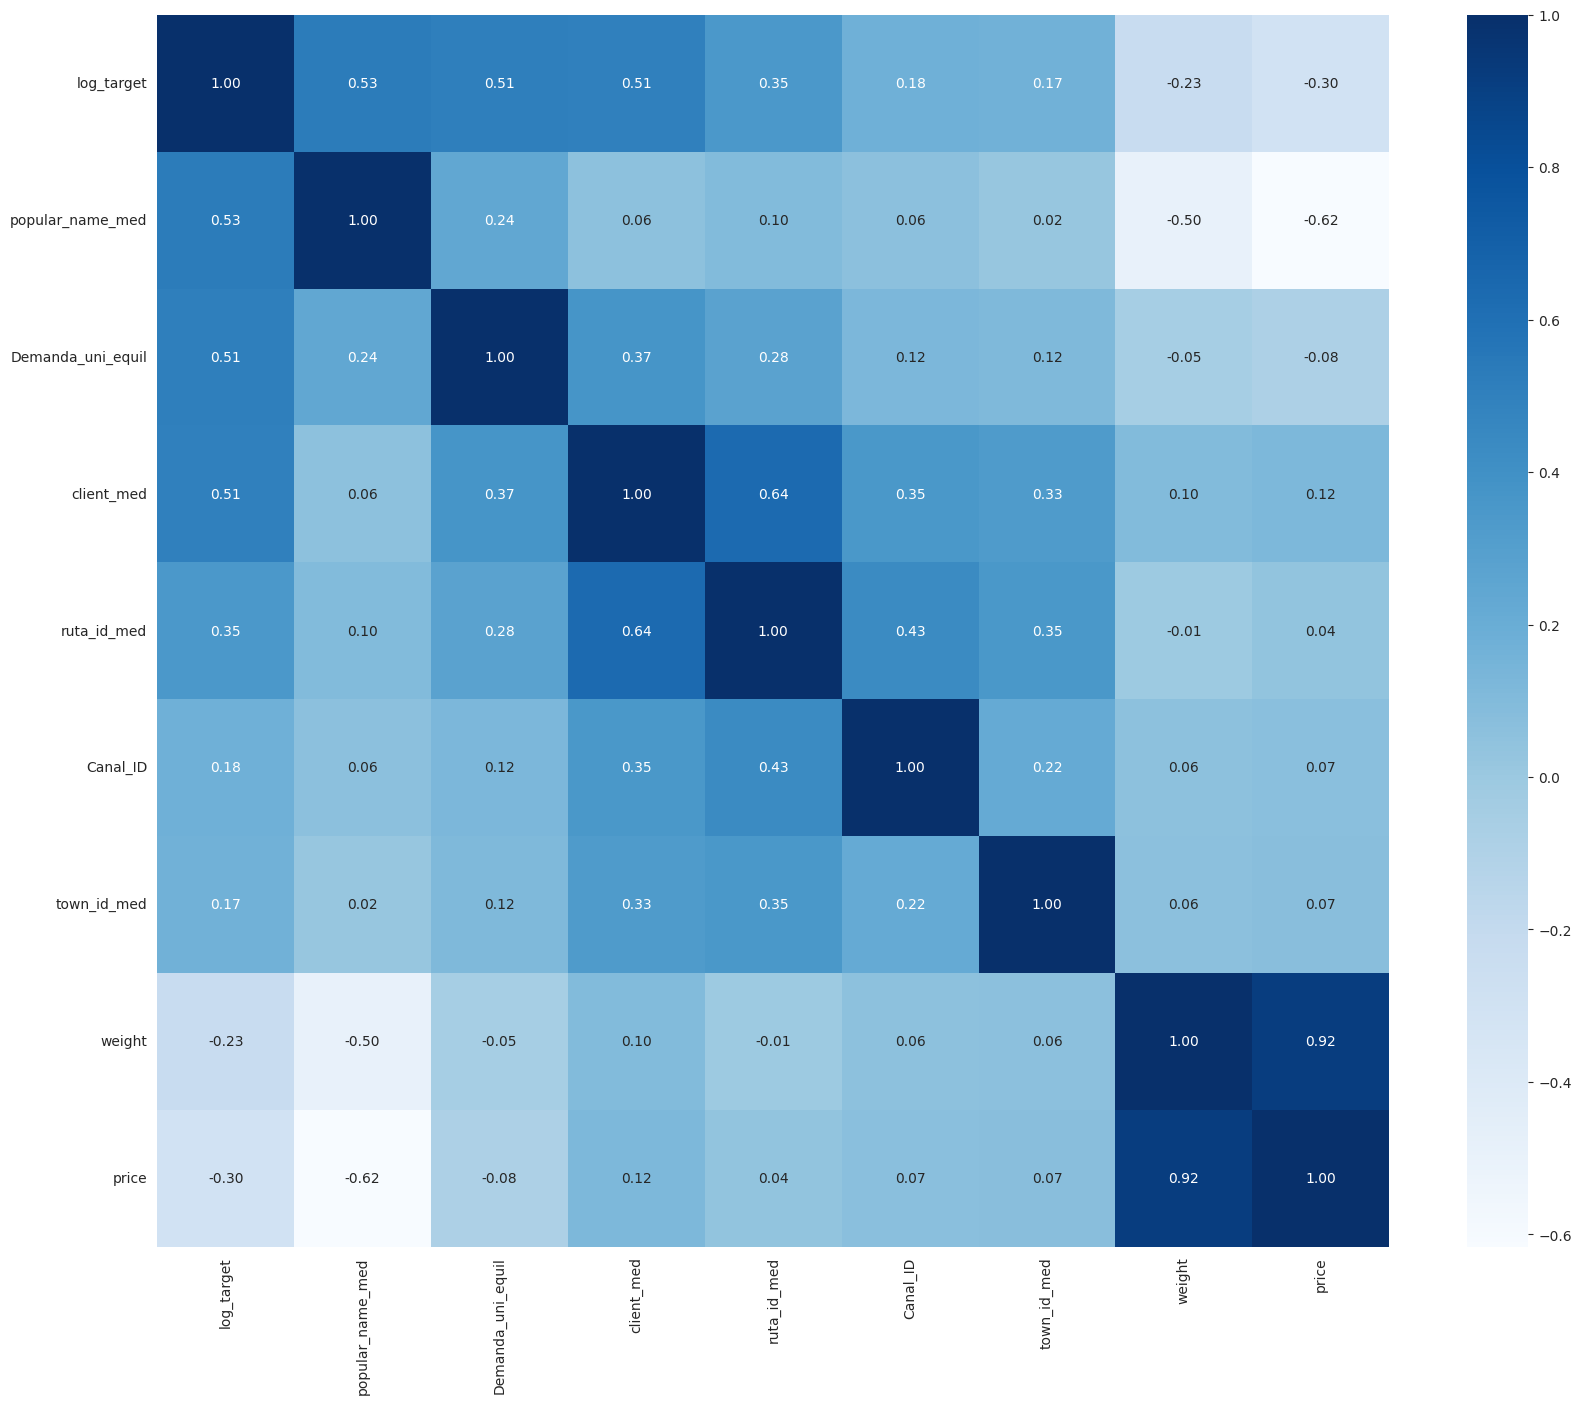

In [82]:
'''correlation matrix'''
plt.subplots(figsize=(20, 16))
k = 20 #number of variables for heatmap
corrmat = sample_train_df.corr()
cols = corrmat.nlargest(k, 'log_target')['log_target'].index

cm = np.corrcoef(sample_train_df[cols].values.T)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True,
                 fmt='.2f', annot_kws={'size': 10}, cmap='Blues',
                 yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [83]:
'''Check feature inportance by applying LightGBM'''
model_lgb = lgb.LGBMRegressor(num_leaves=1000,
                              max_depth=5,
                              learning_rate=0.1,
                              random_state=2)
model_lgb.fit(sample_train_df.drop(['Demanda_uni_equil', 'log_target'], axis=1), sample_train_df['log_target'])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000566 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 7
[LightGBM] [Info] Start training from score 1.603566
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,boosting_type,'gbdt'
,num_leaves,1000
,max_depth,5
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [84]:
df = pd.DataFrame(model_lgb.feature_importances_,
             index=sample_train_df.drop(['Demanda_uni_equil', 'log_target'], axis=1).columns,
             columns=['importance']).sort_values('importance', ascending=False)
df[df.importance > 10]

,importance
client_med,654
price,500
weight,485
popular_name_med,385
ruta_id_med,240
Canal_ID,116
town_id_med,95


<Axes: xlabel='weight', ylabel='log_target'>

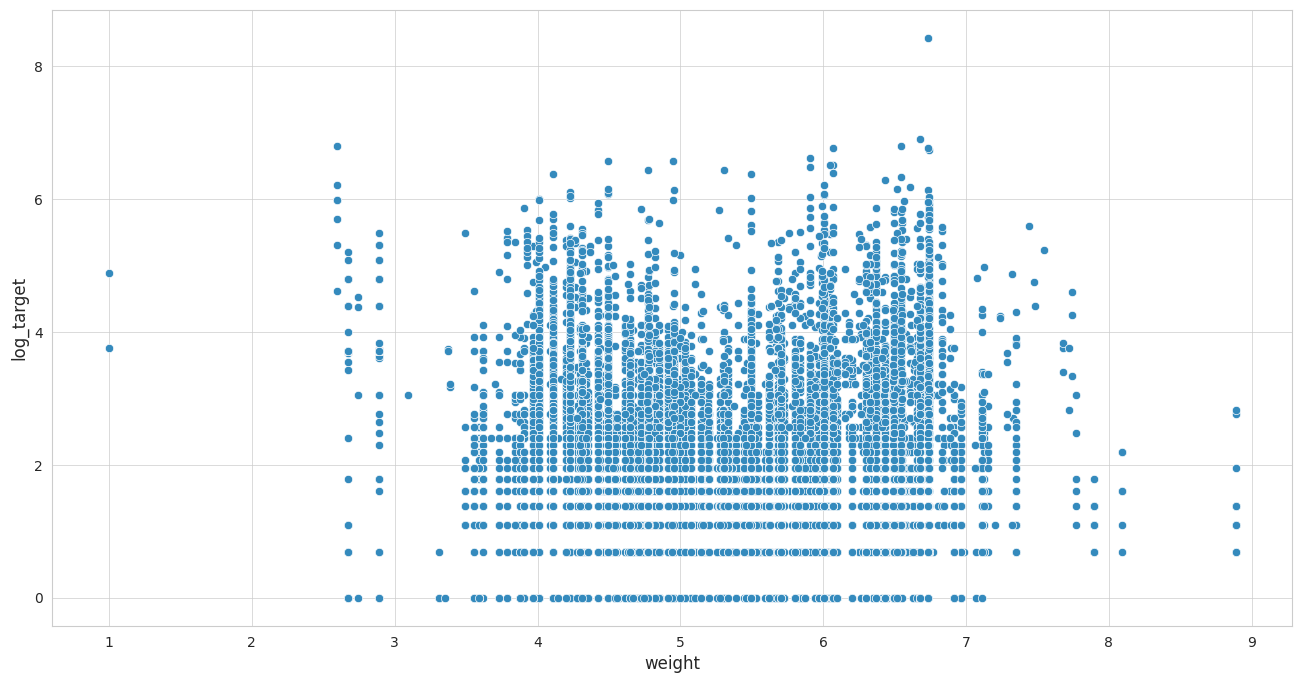

In [85]:
# weight
plt.figure(figsize=(16, 8))
sns.scatterplot(x='weight', y='log_target', data=sample_train_df, palette='Blues_d')

<Axes: xlabel='price', ylabel='log_target'>

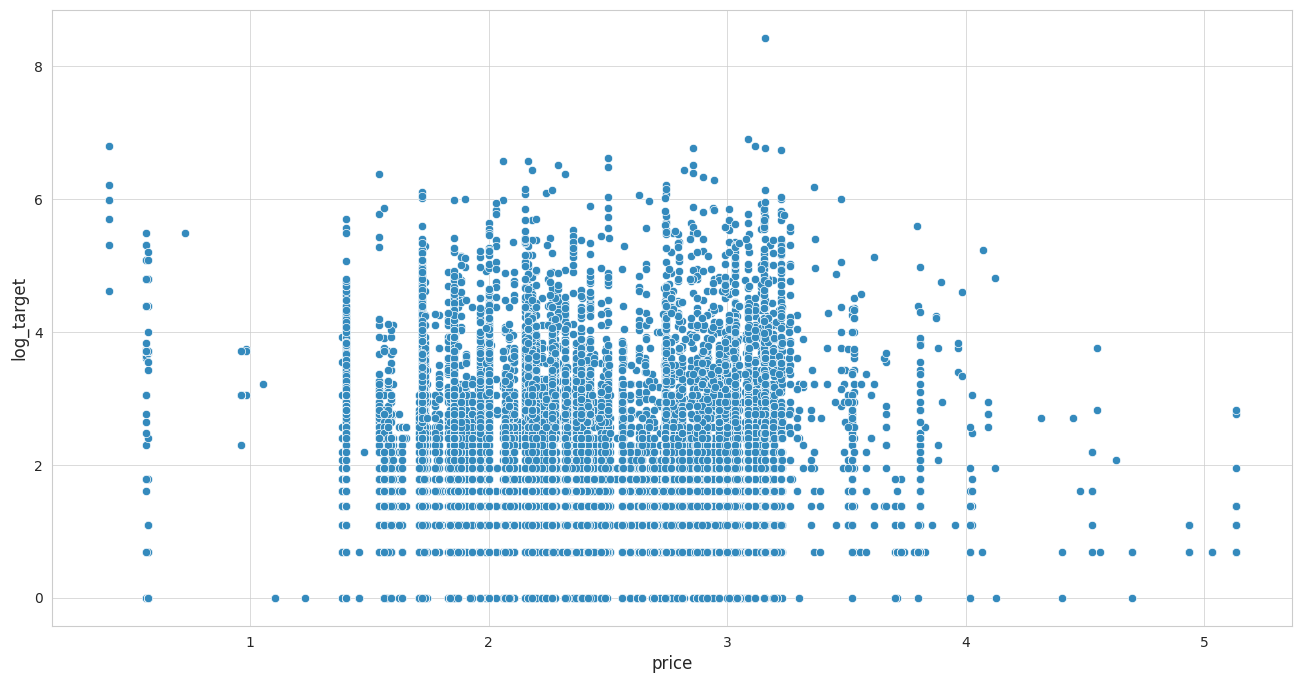

In [86]:
# price
plt.figure(figsize=(16, 8))
sns.scatterplot(x='price', y='log_target', data=sample_train_df, palette='Blues_d')

<Axes: xlabel='client_med', ylabel='log_target'>

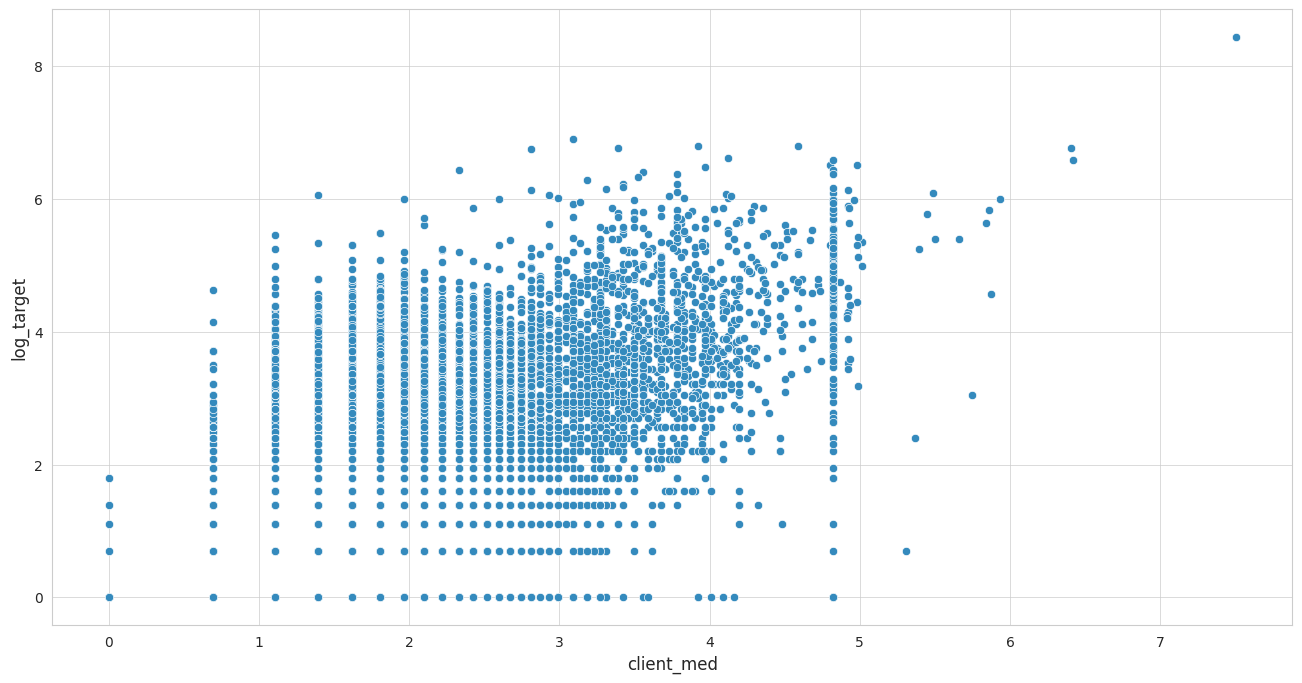

In [87]:
# client_med
plt.figure(figsize=(16, 8))
sns.scatterplot(x='client_med', y='log_target', data=sample_train_df, palette='Blues_d')

<Axes: xlabel='popular_name_med', ylabel='log_target'>

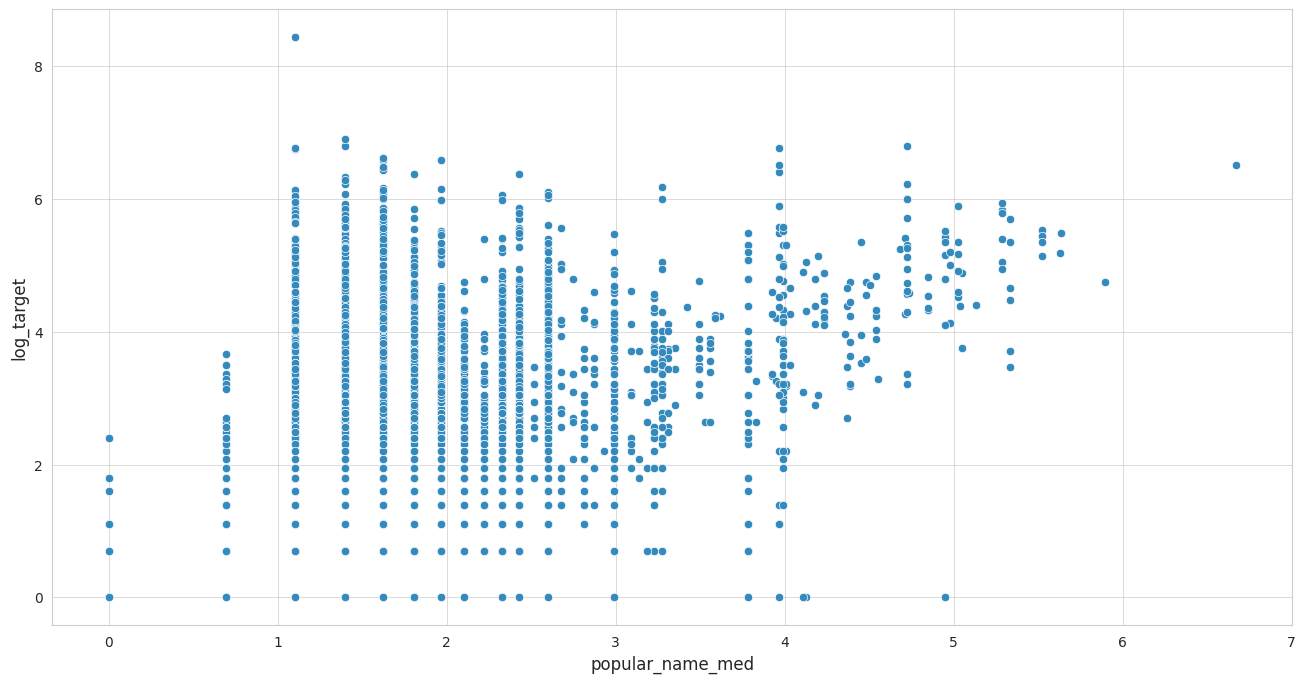

In [88]:
# popular_name_med
plt.figure(figsize=(16, 8))
sns.scatterplot(x='popular_name_med', y='log_target', data=sample_train_df, palette='Blues_d')

<Axes: xlabel='town_id_med', ylabel='log_target'>

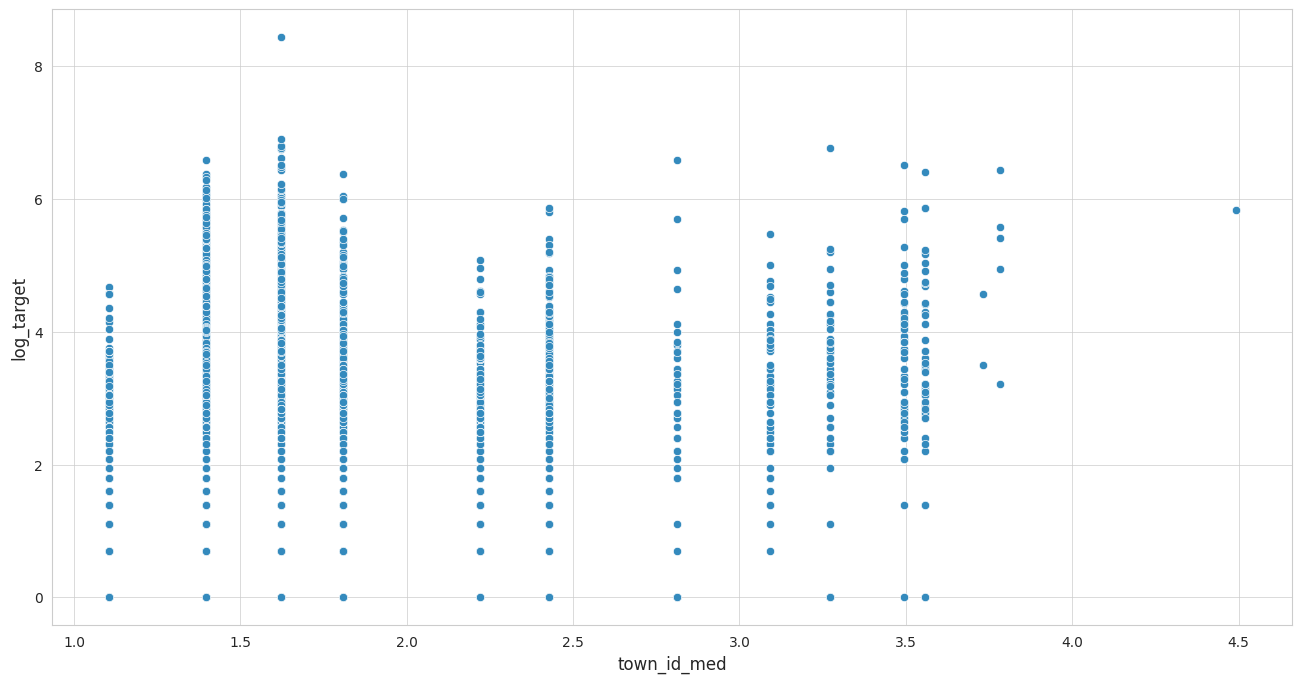

In [89]:
# town_id_med
plt.figure(figsize=(16, 8))
sns.scatterplot(x='town_id_med', y='log_target', data=sample_train_df, palette='Blues_d')

<Axes: xlabel='ruta_id_med', ylabel='log_target'>

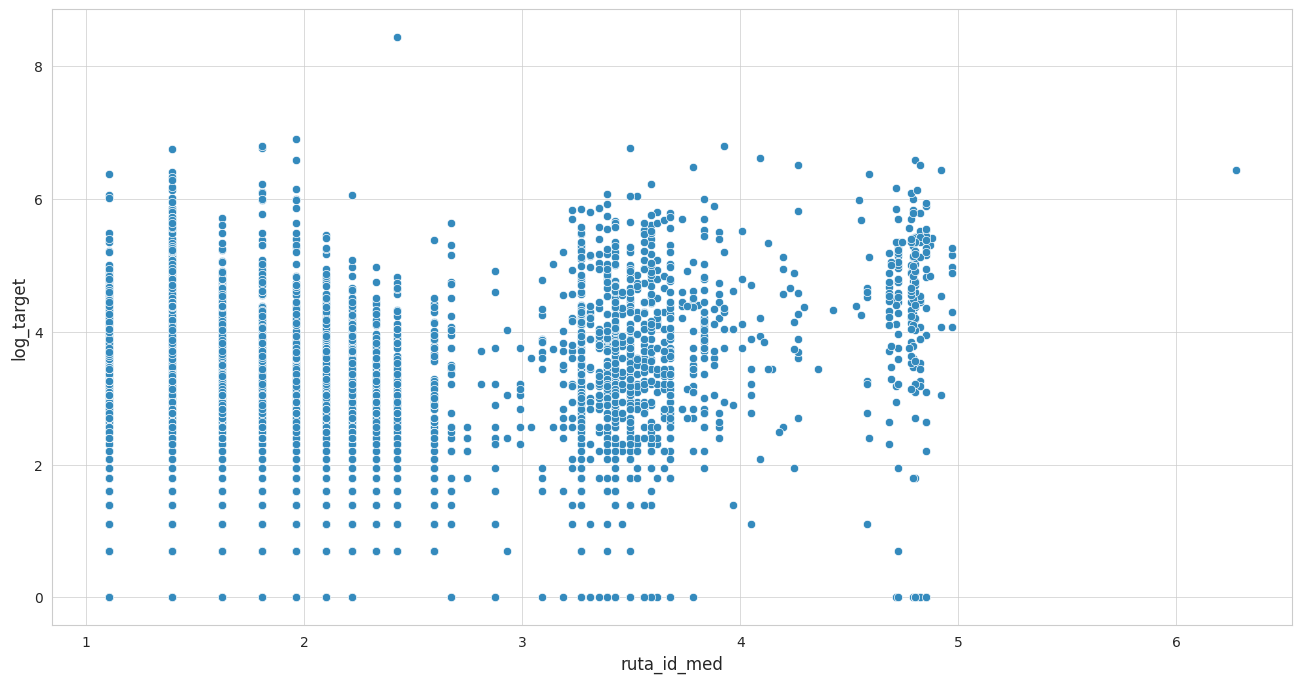

In [90]:
# ruta_id_med
plt.figure(figsize=(16, 8))
sns.scatterplot(x='ruta_id_med', y='log_target', data=sample_train_df, palette='Blues_d')

#### **Models building and comparison**

We use the sampled table for this

#### **Data Preparation**

In [91]:
'''Adjust dataframe for modeling'''
train_y = train_df['Demanda_uni_equil']
train_df.drop(['Demanda_uni_equil'], axis=1, inplace=True)
train_X = pd.get_dummies(train_df)
test_X  = pd.get_dummies(test_df.drop('id', axis=1))

# Free the raw train DataFrame — train_X and train_y now hold everything needed.
# train_df at this point is a large (~74M row) pre-dummies frame no longer referenced.
del train_df
gc.collect()
print(f'train_X: {train_X.shape}  test_X: {test_X.shape}')


train_X: (74180464, 15)  test_X: (6999251, 15)


In [92]:
# (no action needed: sample_train_df is a copy and still has the original
#  Demanda_uni_equil values — no need to reconstruct from log_target)


In [93]:
sample_train_df.head(5)

,Canal_ID,Demanda_uni_equil,weight,price,client_med,popular_name_med,town_id_med,ruta_id_med,log_target
15540764,1,4,5.193,2.327,1.396,1.396,1.622,1.622,1.609
41271897,1,7,4.913,2.470,2.222,1.105,1.622,1.622,2.079
49553689,1,15,4.230,1.719,1.396,2.598,1.396,1.105,2.773
39496965,1,3,4.294,2.070,1.396,1.396,1.396,1.622,1.386
30326590,1,10,5.722,2.222,1.965,1.396,1.396,1.622,2.398


In [94]:
'''Prepare 100K-row sample for fast model comparison'''
sample_train_y = sample_train_df['Demanda_uni_equil']
sample_train_df.drop(['Demanda_uni_equil', 'log_target'], axis=1, inplace=True)
sample_train_X = pd.get_dummies(sample_train_df)

# Free the intermediate sample frame
del sample_train_df
gc.collect()
print(f'sample_train_X: {sample_train_X.shape}')


sample_train_X: (100000, 15)


In [95]:
'''We should use the log transform of the target value'''
class MyEstimator(BaseEstimator):
    def __init__(self, model):
        self.model = model
        
    def fit(self, X, y):
        self.model.fit(X, np.log1p(y))
        return self 

    def predict(self, X):
        predicts = np.expm1(self.model.predict(X))
        mask = (predicts <= 0)
        predicts[mask] = 0
        return predicts

In [96]:
'''Define evaluation function for Convienience'''
def evaluation_model(model, train_X, train_y, test_X):
    cv = rmsle_cv(model, train_X, train_y)
    cv_mean = np.round(cv.mean(), 5)
    cv_std = np.round(cv.std(), 5)
    sample_prediction = model.predict(test_X.loc[:3, :])
    return {'cv_mean': cv_mean, 'cv_std': cv_std, 'sample_prediction': sample_prediction}

In [97]:
'''Define Hyperparameters Tuning Function'''
def tune_hyperparameters(model, param_grid, train_X, train_y):
    grid = GridSearchCV(
        model, param_grid, 
        scoring='neg_mean_squared_log_error',
        cv=3, n_jobs=-1,
    )
    grid.fit(train_X, train_y)
    best_params = grid.best_params_ 
    best_score = np.round(np.sqrt(-1 * grid.best_score_), 5)
    return best_params, best_score

#### **Building Models**
Models done with sampled model 

#### **LinearRegression**

In [98]:
model = make_pipeline(
    RobustScaler(),
    LinearRegression(),
)
lr_model = MyEstimator(model)
lr_model.fit(sample_train_X, sample_train_y)
lr_eval = evaluation_model(lr_model, sample_train_X, sample_train_y, test_X)
print(lr_eval)

{'cv_mean': np.float64(0.5755), 'cv_std': np.float64(0.0048), 'sample_prediction': array([3.9682393, 1.2954038, 3.948999 , 1.92326  ], dtype=float32)}


#### **RidgeCV**

In [99]:
model = make_pipeline(
    RobustScaler(),
    RidgeCV(
        alphas=(0.0001, 0.0005, 0.001, 0.01, 0.05, 0.1, 0.3, 1, 3, 5, 10),
    ),
)
ridge_cv_model = MyEstimator(model)
ridge_cv_model.fit(sample_train_X, sample_train_y)
ridge_cv_eval = evaluation_model(ridge_cv_model, sample_train_X, sample_train_y, test_X)
print(ridge_cv_eval)

opt_alpha = ridge_cv_model.model.steps[1][1].alpha_
print(f'\nopt_alpha: {opt_alpha}')

{'cv_mean': np.float64(0.5755), 'cv_std': np.float64(0.0048), 'sample_prediction': array([3.9681628, 1.2962794, 3.9488988, 1.9233363], dtype=float32)}

opt_alpha: 1.0


#### **ElasticNetCV**

In [100]:
model = make_pipeline(
    RobustScaler(),
    ElasticNetCV(
        alphas=(0.00001, 0.0001, 0.0002, 0.0003), 
        l1_ratio=(0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5),
    ),
)
elsnt_cv_model = MyEstimator(model)
elsnt_cv_model.fit(sample_train_X, sample_train_y)
elsnt_cv_eval = evaluation_model(elsnt_cv_model, sample_train_X, sample_train_y, test_X)
print(elsnt_cv_eval)

opt_alpha = elsnt_cv_model.model.steps[1][1].alpha_
opt_l1_ratio = elsnt_cv_model.model.steps[1][1].l1_ratio_
print(f'\nopt_alpha: {opt_alpha} opt_l1_ratio: {opt_l1_ratio}')

{'cv_mean': np.float64(0.57548), 'cv_std': np.float64(0.0048), 'sample_prediction': array([3.9698467, 1.3064135, 3.94831  , 1.9259198], dtype=float32)}

opt_alpha: 0.0001 opt_l1_ratio: 0.5


### **SVR**

In [101]:
# {'cv_mean': 0.57025, 'cv_std': 0.00775, 'sample_prediction': array([3.85650165, 1.24517075, 3.45866592])}

# grid best_params: {'model__svr__C': 10, 'model__svr__epsilon': 0.1, 'model__svr__gamma': 0.01}

# ### build basemodel
model = make_pipeline(
    RobustScaler(),
    SVR(),
)
svr_model = MyEstimator(model)
# 
# ### optimize hyperparameters
param_grid = {'model__svr__C': [1, 10, 20],
              'model__svr__epsilon': [0.001, 0.01, 0.1],
              'model__svr__gamma': [0.0001, 0.001, 0.01]}
best_params, best_score = \
    tune_hyperparameters(svr_model, param_grid, sample_train_X, sample_train_y)
# 
# ### fit using best_params
svr_model.set_params(**best_params)
svr_model.fit(sample_train_X, sample_train_y)
svr_eval = evaluation_model(svr_model, sample_train_X, sample_train_y, test_X)
print(svr_eval)
# 
print(f'\ngrid best_params: {best_params}')

{'cv_mean': np.float64(0.55834), 'cv_std': np.float64(0.00456), 'sample_prediction': array([3.73964034, 1.25674642, 3.40851778, 1.62838432])}

grid best_params: {'model__svr__C': 20, 'model__svr__epsilon': 0.1, 'model__svr__gamma': 0.01}


#### **LightGBM**

In [102]:
model = LGBMRegressor(learning_rate=0.01, n_estimators=3000,
                      num_leaves=5,
                      objective='regression',
                      max_bin=55, bagging_fraction=0.8,
                      bagging_freq=5, feature_fraction=0.2319,
                      feature_fraction_seed=9, bagging_seed=9,
                      min_data_in_leaf=6, min_sum_hessian_in_leaf=11)
lgb_model = MyEstimator(model)
lgb_model.fit(sample_train_X, sample_train_y)
lgb_eval = evaluation_model(lgb_model, sample_train_X, sample_train_y, test_X)
print(lgb_eval)

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319

#### **XGBOOST**

In [104]:

# Wrap in MyEstimator so training is done on log1p(y) and predict() returns
# raw demand values (expm1 applied internally) — same as all other models.
XGB_model = MyEstimator(
    xgb.XGBRegressor(
        objective='reg:squarederror',
        max_depth=8,
        learning_rate=0.0018,
        n_estimators=1160,
    )
)
XGB_model.fit(sample_train_X, sample_train_y)
XGB_eval = evaluation_model(XGB_model, sample_train_X, sample_train_y, test_X)
print(XGB_eval)


{'cv_mean': np.float64(0.55103), 'cv_std': np.float64(0.00368), 'sample_prediction': array([4.6337557, 1.6968237, 3.4690914, 1.9890206], dtype=float32)}


In [105]:
def output_submission_file(model, test_X, model_name='model'):
    from datetime import datetime
    # 1. Timestamp
    timestamp = datetime.now().strftime("%m%d_%H%M")
    filename = f"submission_{model_name}_{timestamp}.csv"

    # 2. Predict
    # MyEstimator.predict() already returns raw demand values
    # (it applies expm1 internally after predicting on log1p-transformed target).
    # Do NOT apply expm1 again here — that would double-exponentiate.
    prediction = model.predict(test_X)
    prediction = np.maximum(prediction, 0)   # clip negatives to 0

    # 3. Build submission DataFrame
    df = pd.DataFrame({
        'id': test_df['id'],
        'Demanda_uni_equil': prediction
    })

    print(f'Shape: {df.shape}')
    print(df.head(5))

    # 4. Save
    df.to_csv(filename, index=False)
    print(f'Successfully saved to: {filename}')
    return filename


#### **Model Comparison and final prediction with whole dataset**

In [106]:
# Collect evaluation results from all trained models
# Each eval dict has keys: cv_mean, cv_std, sample_prediction
model_results = {
    'LinearRegression': lr_eval,
    'RidgeCV':          ridge_cv_eval,
    'ElasticNetCV':     elsnt_cv_eval,
    'SVR':              svr_eval,
    'LightGBM':         lgb_eval,
    'XGBoost':          XGB_eval,
}

comparison_df = pd.DataFrame([
    {
        'Model':    name,
        'CV RMSLE (mean)': res['cv_mean'],
        'CV RMSLE (std)':  res['cv_std'],
    }
    for name, res in model_results.items()
]).sort_values('CV RMSLE (mean)')

print("=" * 55)
print("MODEL COMPARISON  (3-fold cross-val RMSLE on 100K sample)")
print("=" * 55)
print(comparison_df.to_string(index=False))
print()

# ── Pick the best model ───────────────────────────────────────
best_model_name = comparison_df.iloc[0]['Model']
best_rmsle      = comparison_df.iloc[0]['CV RMSLE (mean)']

model_map = {
    'LinearRegression': lr_model,
    'RidgeCV':          ridge_cv_model,
    'ElasticNetCV':     elsnt_cv_model,
    'SVR':              svr_model,
    'LightGBM':         lgb_model,
    'XGBoost':          XGB_model,
}

best_model = model_map[best_model_name]

print(f"✅  Best model : {best_model_name}")
print(f"   CV RMSLE   : {best_rmsle}")
print()

MODEL COMPARISON  (3-fold cross-val RMSLE on 100K sample)
           Model  CV RMSLE (mean)  CV RMSLE (std)
         XGBoost            0.551           0.004
        LightGBM            0.554           0.004
             SVR            0.558           0.005
    ElasticNetCV            0.575           0.005
LinearRegression            0.576           0.005
         RidgeCV            0.576           0.005

✅  Best model : XGBoost
   CV RMSLE   : 0.55103

RETRAINING ON FULL DATASET
  Training rows : 74,180,464
  Features      : 15

Full-data CV RMSLE  mean=0.54687  std=6e-05



#### **Retrain winner model with full dataset**

In [108]:
print("=" * 55)
print("RETRAINING ON FULL DATASET")
print(f"  Training rows : {train_X.shape[0]:,}")
print(f"  Features      : {train_X.shape[1]}")
print("=" * 55)

best_model.fit(train_X, train_y)

# Final CV score on the full dataset
full_cv = rmsle_cv(best_model, train_X, train_y)
print(f"\nFull-data CV RMSLE  mean={np.round(full_cv.mean(), 5)}  "
      f"std={np.round(full_cv.std(), 5)}")
print()

RETRAINING ON FULL DATASET
  Training rows : 74,180,464
  Features      : 15

Full-data CV RMSLE  mean=0.54687  std=6e-05



#### **Submission preparation**

Here we select the best model and we perform the model on the total size of the dataframe

In [109]:
# Generate submission with the best model trained on full data
output_submission_file(best_model, test_X, best_model_name.lower().replace(' ', '_'))

Shape: (6999251, 2)
   id  Demanda_uni_equil
0   0              4.327
1   1              1.692
2   2              3.400
3   3              1.964
4   4              2.211
Successfully saved to: submission_xgboost_0326_2104.csv


'submission_xgboost_0326_2104.csv'